In [22]:
from utility.plot_from_hdf5 import plot_from_hdf5
from utility.my_colors import palette_dark, palette_light
from utility.contour_scatter_plot import contour_scatter_plot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast

from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde

RESULTS_PATH = "data/results.csv"
FIT_PARAMS_PATH = "data/fit_params.csv"
DETAILS_PATH = "data/result_details.csv"
RELEVANT_RESULTS_PATH = "data/relevant_results.csv"

plt.rcdefaults()

settings = {
        'font.size':16,
        'xtick.direction':'in', 
#         # 'xtick.minor.visible':True,
#         # 'xtick.top':True,
        'ytick.direction':'in', 
#         # 'ytick.minor.visible':True,
#         # 'ytick.right':True,
        'xtick.major.size':4.0,
        'xtick.minor.size':2.0,
        'ytick.major.size':4.0,
        'ytick.minor.size':2.0,
        'legend.frameon':False,
        # 'mathtext.fontset':'stix',
        # 'font.family':'STIXGeneral'
    }

plt.rcParams.update(**settings)

In [5]:
results = pd.read_csv(RELEVANT_RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186890 entries, 39628261600268308 to 39627768828270015
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   rew_civ                  186890 non-null  float64
 1   rew_nv                   186890 non-null  float64
 2   rew_lya                  186890 non-null  float64
 3   snr_1700A                186888 non-null  float64
 4   snr_civ                  186890 non-null  float64
 5   snr_nv                   186890 non-null  float64
 6   snr_lya                  186890 non-null  float64
 7   pixel_used_civ           186890 non-null  float64
 8   pixel_used_blue_end_lya  186890 non-null  float64
 9   continuum_redchi         186890 non-null  float64
 10  z                        186890 non-null  float64
 11  zerr                     186890 non-null  float64
 12  civ_1549_flux            186890 non-null  float64
 13  civ_1549_flux_ivar       186890 non-n

### Check the subsequent samples like in Hamann
Objects that were processed (i.e. those from the initial SQL query) satisfy
`(zp.z BETWEEN 2.2 AND 4.38) AND (zp.zwarn=0) AND (agn.civ_1549_flux>0) AND (zp.spectype='QSO') AND zp.zcat_primary`

#### Full sample
- 2 < z 3.4 (lowest values are 2.2 not 2)
- warning=False which includes: SNR CIV > 2.5, continuum redchi2 < 2, all REW > 0 and not null, CIV at least 70% pixel used, Lya at least 65% pixel used on left side, z flux is larger 0 and not null

In [6]:
full = results[(results["z"] > 2) & (results["z"] < 3.4)].copy()
full["Sample"] = "Full"
full_idx = full.index
full

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,30.873547,79.327994,1578.572653,1755.868659,4467.502691,3253.396449,3251.881116,2260.575301,0.249399,Full
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,39.221570,80.179306,702.093410,373.690555,886.189289,5004.121189,4996.055063,2496.704981,0.238525,Full
39627901502489216,61.661126,50.066402,56.991357,0.736838,6.510926,4.934822,8.353253,0.962441,0.832898,0.150371,...,51.046492,63.236045,238.614723,241.211185,280.171174,5395.436113,5387.128039,4360.419360,0.234584,Full
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,67.106677,30.577277,908.245722,1909.709200,696.782583,7004.388592,6992.688130,3046.948259,0.324565,Full
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,52.529956,42.194407,881.968932,850.503658,742.675782,7365.153111,7353.267331,4962.357216,0.226158,Full
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628053415987103,118.962903,49.831986,92.167040,0.680706,2.613462,0.727741,1.646045,0.920596,0.889807,0.038240,...,45.596857,100.022424,84.395460,41.496963,78.308778,4527.744460,4535.865791,4139.097371,0.231864,Full
39627983115257786,52.601683,27.833232,38.173872,0.953028,8.233751,6.199389,12.435801,0.997835,0.828916,0.280892,...,33.765478,41.641763,641.849498,428.851538,603.353178,6748.325156,6737.115628,5221.039957,0.242868,Full
39627926517322439,88.433732,33.716419,139.284764,0.519953,12.028317,5.543115,18.376339,0.950108,0.840580,0.050119,...,32.918452,138.756640,197.663768,105.628622,450.723156,2341.986219,2341.278198,2033.014791,0.270749,Full


#### W3-detected
- SNR(W3) > 3

In [7]:
w3_detected = full.query("snr_w3 > 3").copy()
w3_detected["Sample"] = "W3 detected"
w3_detected_idx = w3_detected.index
w3_detected

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,30.873547,79.327994,1578.572653,1755.868659,4467.502691,3253.396449,3251.881116,2260.575301,0.249399,W3 detected
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,39.221570,80.179306,702.093410,373.690555,886.189289,5004.121189,4996.055063,2496.704981,0.238525,W3 detected
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,67.106677,30.577277,908.245722,1909.709200,696.782583,7004.388592,6992.688130,3046.948259,0.324565,W3 detected
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,52.529956,42.194407,881.968932,850.503658,742.675782,7365.153111,7353.267331,4962.357216,0.226158,W3 detected
39627779037202942,41.069234,52.377690,17.228492,0.655766,2.868326,2.217354,3.632044,0.950588,0.879581,0.106126,...,43.567645,18.367051,101.499588,172.368010,57.564280,5503.989179,5494.918240,1743.896308,0.253387,W3 detected
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632961531806138,68.280006,61.465376,127.422601,0.520987,3.496122,3.179693,4.785442,0.933602,0.887892,0.083141,...,74.313305,145.025455,68.275819,67.038541,138.726613,5072.738838,5078.892571,6232.192289,0.262452,W3 detected
39627915016539584,32.306415,36.275146,19.276486,0.970341,10.217814,8.539332,6.160885,0.908676,0.783715,0.737209,...,45.084766,24.134494,616.826902,850.030266,465.566363,6061.770891,6051.918394,4207.913901,0.235826,W3 detected
39628382106812614,36.539355,31.760665,50.060707,0.803729,6.521420,5.596410,12.129493,0.982340,0.790588,0.060873,...,30.639997,50.611621,319.207859,328.347364,525.811885,4435.790432,4436.779084,2583.511499,0.234770,W3 detected


#### ERQs
- z-W3 > 3.9

In [8]:
erq = w3_detected[w3_detected["z-w3"] > 3.9].copy()
erq["Sample"] = "ERQ"
erq_idx = erq.index
erq

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39627779037202942,41.069234,52.377690,17.228492,0.655766,2.868326,2.217354,3.632044,0.950588,0.879581,0.106126,...,43.567645,18.367051,101.499588,172.368010,57.564280,5503.989179,5494.918240,1743.896308,0.253387,ERQ
39627699790024199,54.296104,49.135866,70.136264,0.736011,6.149229,4.306026,10.850016,0.966667,0.767742,0.470200,...,46.295448,72.000721,269.308325,270.468872,392.309264,4810.223967,4802.497872,2880.468972,0.301892,ERQ
39628123985153993,125.232001,59.333197,394.957945,0.566372,3.777197,2.119422,10.053563,0.897216,0.875598,0.065059,...,74.504683,408.076060,74.910659,42.058782,280.985594,2736.066292,2736.942211,2436.999237,0.354027,ERQ
39628410783271554,89.148791,37.180647,54.512249,0.729147,4.183250,1.920362,4.650294,0.980296,0.872928,0.011805,...,41.075506,58.197953,250.329587,160.406223,245.082476,5333.544384,5324.768893,5147.189275,0.238072,ERQ
39628017118484156,69.084521,30.747853,65.695091,0.735615,3.597611,1.550206,2.602071,0.937238,0.842920,0.005644,...,38.555854,71.679024,109.690129,58.266969,128.186091,3098.068322,3101.563283,2681.904379,0.237146,ERQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628257213028100,58.748484,39.964032,95.143695,0.455924,3.710882,0.931673,4.008748,0.887133,0.879093,0.037589,...,38.808723,103.421342,57.212552,37.382676,88.044224,1544.838621,1548.736996,1742.937950,0.193428,ERQ
39627981827606141,43.335297,37.726595,33.696240,0.820696,3.186362,1.079839,3.451561,0.958025,0.903846,0.022352,...,31.636476,33.417698,93.913667,85.048706,76.108319,5886.729163,5877.097949,3141.389888,0.227888,ERQ
39627567950466529,27.040848,9.697804,36.252028,0.582844,4.036805,2.470379,8.181252,0.917526,0.747706,0.079300,...,22.278524,49.139704,204.505576,84.783761,328.567986,7352.573994,7364.694387,4137.069754,0.296886,ERQ


#### Core ERQs
- REW(CIV) > 100

In [9]:
core_erq = erq[erq["rew_civ"] > 100]
core_erq_idx = core_erq.index
core_erq

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628123985153993,125.232001,59.333197,394.957945,0.566372,3.777197,2.119422,10.053563,0.897216,0.875598,0.065059,...,74.504683,408.076060,74.910659,42.058782,280.985594,2736.066292,2736.942211,2436.999237,0.354027,ERQ
39628072797866727,470.986602,93.509273,315.010605,0.552134,4.489033,1.061074,3.148873,0.953431,0.923497,0.011409,...,121.484755,337.753605,137.813298,37.926078,130.347061,3531.641976,3526.612645,2230.649285,0.241008,ERQ
39627891113201923,112.219588,62.672895,99.054101,0.606324,5.955274,2.710882,7.278569,0.983945,0.908163,0.016740,...,64.175805,97.136269,168.987387,121.849523,196.661733,7779.767027,7766.704920,2365.939453,0.372357,ERQ
39627780903669053,140.798530,249.117161,53.101180,0.543534,4.137893,5.718557,1.320132,0.901119,0.854470,0.004901,...,299.202272,138.779761,63.974277,105.536849,22.320187,2529.297899,2530.247288,6773.692334,0.351498,ERQ
39628396275177020,171.882397,39.498231,197.261087,0.697958,4.498471,0.809909,6.562073,0.978599,0.891540,0.002679,...,29.507003,190.096757,177.606102,60.731517,310.860502,4464.904177,4472.554377,1887.898275,0.235758,ERQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39632971719774209,107.142013,40.204052,90.573330,0.451184,2.535676,0.928699,2.889068,0.950237,0.883905,0.026021,...,52.817816,106.850193,82.582710,35.124023,81.524699,6280.214439,6276.672312,3343.599854,0.244395,ERQ
39627606353513953,262.600709,133.373283,372.368041,0.875102,4.632945,2.508304,5.879460,0.912281,0.878049,0.042191,...,143.146019,404.085167,68.373912,51.797066,141.663679,1881.783099,1883.899711,1873.157476,0.352662,ERQ
39627897656312134,177.743800,54.117060,459.072967,1.142572,3.396098,0.698038,2.474661,0.840580,0.902965,0.022673,...,48.875308,509.715404,46.574391,15.453301,130.559180,1368.113618,1369.526758,1742.997973,0.372517,ERQ


#### REW(CIV) > 100

In [10]:
large = full.query("rew_civ > 100").copy()
large_idx = large.index
large["Sample"] = "Large"
large

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628412662323165,161.601504,66.853313,24.886163,0.661391,5.145252,2.287900,1.508265,0.990172,0.836066,0.051041,...,97.918390,46.506675,312.551058,172.708966,66.286349,6157.448766,6147.276882,3865.514543,0.231917,Large
39628481855754778,149.066299,45.077878,88.992064,0.626327,4.060759,1.097277,2.594436,0.956190,0.881356,0.008430,...,52.837864,110.339125,111.886956,36.090498,72.030086,4415.217735,4407.751356,4426.295422,0.248055,Large
39627985698953905,134.089950,59.402374,94.582893,0.558191,8.832818,2.819567,7.060071,0.993135,0.884615,0.168216,...,59.768305,98.564059,528.413473,297.357835,484.507598,5025.185630,5016.763647,4696.221716,0.242982,Large
39627497754594111,107.996366,35.047851,123.960369,0.423711,6.565238,1.992941,7.510495,0.963325,0.925824,0.083516,...,35.319866,123.191551,233.432668,104.124874,380.926539,3380.669722,3376.700628,2172.249027,0.275029,Large
39628495797618139,181.144207,35.396888,159.440111,0.747491,3.404237,1.493232,2.868796,0.917595,0.863524,0.026513,...,66.708317,202.723108,94.571626,21.993908,100.743943,5329.609541,5320.673323,5787.762262,0.245590,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39627766093584889,100.659055,34.724141,74.987139,0.694299,4.940178,1.772425,5.475085,0.967442,0.888601,0.020050,...,44.420492,81.118414,197.145220,88.004187,194.620464,5189.891896,5181.619930,2452.828302,0.229893,Large
39628337403923861,104.989620,31.105850,101.069486,0.652475,4.819678,0.978631,3.843473,0.977612,0.889197,0.066478,...,31.079209,98.970324,208.883345,87.152896,291.297392,4813.784514,4805.810946,2203.319066,0.240380,Large
39628259347926729,113.953401,41.878910,118.952360,0.715565,4.402226,1.670195,2.452027,0.949398,0.908602,0.030174,...,55.373829,144.621351,107.152716,41.973889,120.600626,4294.859877,4297.107847,6293.627562,0.282238,Large


#### ERQ-like

In [11]:
erq_like = results[(results["flux_z"] > 0) & (~results["flux_z"].isna()) & ((results["z"] >= 3.4) | (results["z"] <= 2)) & (results["snr_w3"] > 3) & (results["z-w3"] > 3.9) & (results["rew_civ"] > 100)]
erq_like

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_civ,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ
targetid,,,,,,,,,,,,,,,,,,,,,
39627426392705320,296.410430,75.963788,783.625271,0.611509,5.817667,1.225289,11.043085,0.866667,0.881508,0.042469,...,318.035167,72.498077,803.769975,101.964719,33.120592,349.835422,1367.448579,1369.368627,1742.803976,0.372323
39633178507349341,105.085803,41.085984,115.111635,0.772877,3.312947,0.856665,4.361371,0.937608,0.844106,0.034881,...,111.183275,42.064016,115.788107,137.851291,73.799913,211.798105,4117.412640,4111.391781,1910.167773,0.263672
39628126220717383,251.831211,74.322837,873.843949,0.508663,14.409286,2.896687,26.839937,0.934708,0.873805,0.038865,...,253.387390,68.728460,839.143962,225.027814,72.555396,856.874822,2008.983224,2011.381795,1978.341692,0.333489
39627895701771431,160.247221,130.753993,459.853804,0.808858,15.534038,11.742577,13.877827,0.912752,0.876636,0.117165,...,161.672010,118.476578,360.903088,148.382875,139.568097,497.170154,1385.689203,1386.421510,1743.066778,0.367116
39627969089508216,118.084380,85.514377,131.496712,0.712455,3.038111,1.552084,4.863176,0.947748,0.845691,0.017470,...,126.064684,85.852070,142.140022,139.706572,88.854344,135.361639,5576.716781,5571.077697,2086.126485,0.316796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39627748838213786,195.626961,52.708381,625.742447,0.809843,13.893303,3.873663,38.419054,0.954186,0.769772,0.107228,...,196.477763,50.825143,619.505440,250.791402,77.868166,935.528766,2350.689285,2350.634826,2210.718278,0.339712
39627793310419339,351.186084,114.688297,1425.636572,0.685749,4.788898,1.545809,14.646378,0.898693,0.890909,0.031318,...,382.575713,114.761987,1473.098935,53.098067,17.763462,214.237903,1396.070162,1397.728452,1757.505666,0.363997
39628043488067651,122.952827,168.268545,929.841274,0.713584,5.093910,2.590932,3.000896,0.915789,0.910156,0.020776,...,121.342294,268.605212,907.771167,78.173371,42.530720,226.006256,1432.951898,1435.092018,4428.370270,0.349712


### Plots

In [12]:
full = full.drop(index=["39627636372146550"])  # super large CIV REW

#### Evaluate method

#### Histogram: REW colored by object type

In [10]:
# histplot_df = full.copy()

# histplot_df["Sample"] = "Full"
# temp1 = erw

# for elem in histplot_df.index:
#     # if elem in core_erq_idx: 
#     if elem in erq_idx:
#         histplot_df.loc[elem,"Sample"] = "ERQ"
#     elif elem in w3_detected_idx:
#         histplot_df.loc[elem,"Sample"] = "W3 detected"
histplot_df = pd.concat([full,w3_detected,erq]).reset_index(drop=False)

histplot_df["Sample"].value_counts()

hue_order = ["Full", "W3 detected", "ERQ"]
hist_palette = ["gray", palette_dark[2], palette_dark[0]]

[]

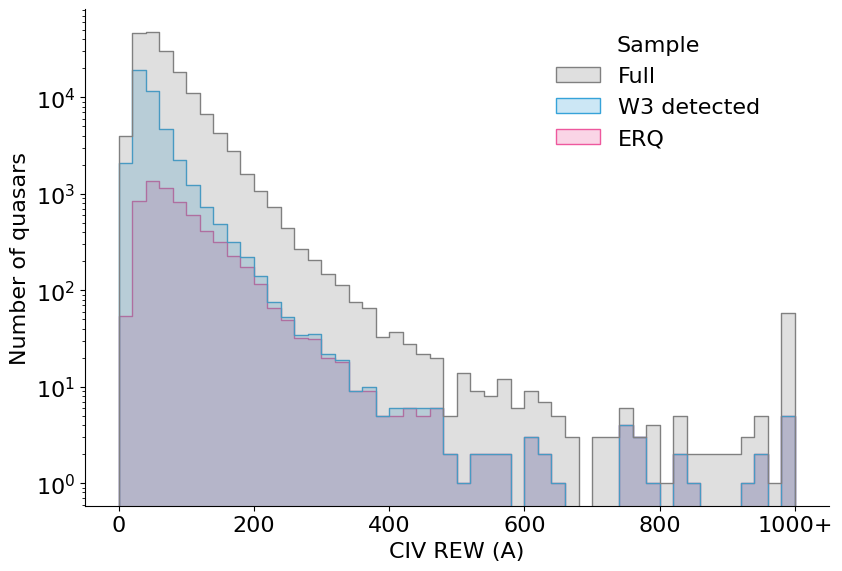

In [11]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

civ_histplot = histplot_df[["rew_civ", "fwhm_civ","Sample"]].copy()

civ_histplot["rew_civ"] = civ_histplot["rew_civ"].clip(upper=1000)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=civ_histplot, x="rew_civ", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")

xticks = list(range(0,1001,200))#ax.get_xticks()
ax.set_xticks(xticks)
xticklabels = [str(int(t)) for t in xticks]
xticklabels[-1] = "1000+"
ax.set_xticklabels(xticklabels)

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("CIV REW (A)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

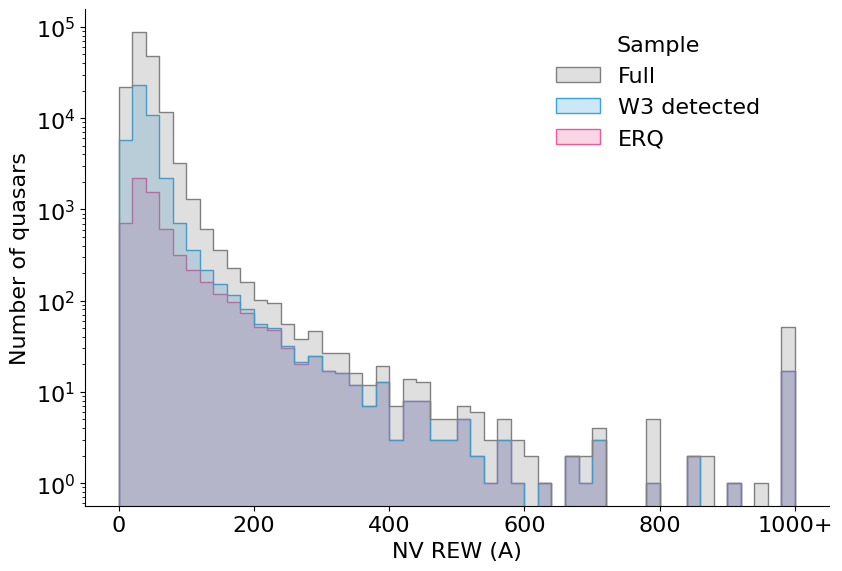

In [12]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

nv_histplot = histplot_df[["rew_nv","fwhm_nv","Sample"]].copy()

nv_histplot["rew_nv"] = nv_histplot["rew_nv"].clip(upper=1000)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=nv_histplot, x="rew_nv", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")

# plt.xlim(-5,1005)

xticks = list(range(0,1001,200))#ax.get_xticks()
ax.set_xticks(xticks)
xticklabels = [str(int(t)) for t in xticks]
xticklabels[-1] = "1000+"
ax.set_xticklabels(xticklabels)

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("NV REW (A)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

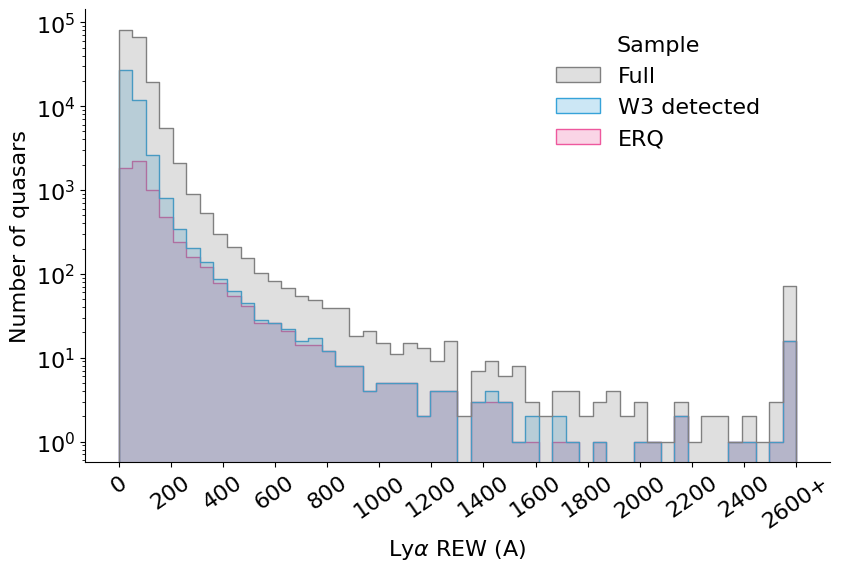

In [13]:
# plt.subplots(figsize=(8,5))
# sns.set_context("notebook")

lya_histplot = histplot_df[["rew_lya","fwhm_lya","Sample"]].copy()#

lya_histplot["rew_lya"] = lya_histplot["rew_lya"].clip(upper=2600)

# bin_edges = list(np.linspace(histplot_df["rew_civ"].min(), 1000, 50)) + [full["rew_civ"].max()]

g = sns.displot(data=lya_histplot, x="rew_lya", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)#, bins=bin_edges)

ax = g.ax

plt.yscale("log")


xticks = list(range(0,2601,200))#ax.get_xticks()
ax.set_xticks(xticks)
xticklabels = [str(int(t)) for t in xticks]
xticklabels[-1] = "2600+"
ax.set_xticklabels(xticklabels,rotation=35)


sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel(r"Ly$\alpha$ REW (A)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

#### Histogram: FWHM colored by object type

[]

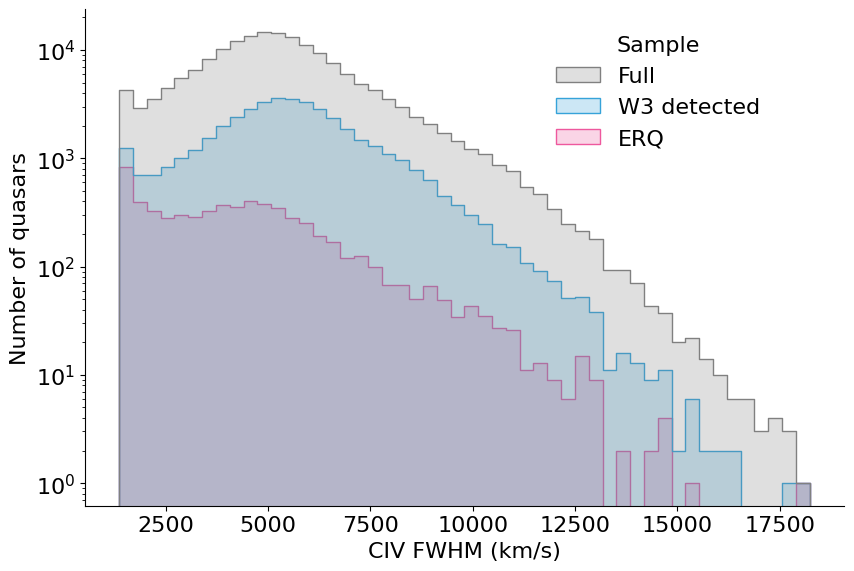

In [14]:
g = sns.displot(data=civ_histplot, x="fwhm_civ", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)

ax = g.ax

plt.yscale("log")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("CIV FWHM (km/s)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

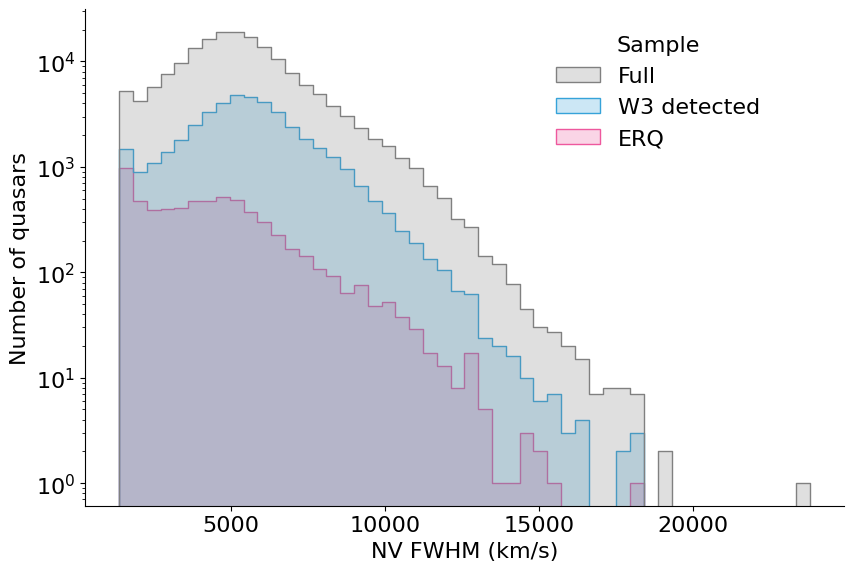

In [15]:
g = sns.displot(data=nv_histplot, x="fwhm_nv", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)

ax = g.ax

plt.yscale("log")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel("NV FWHM (km/s)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

[]

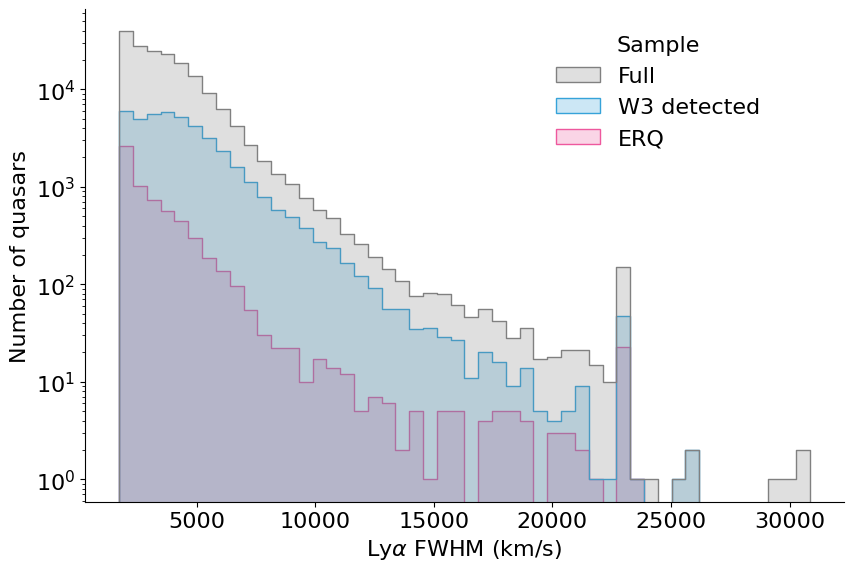

In [16]:
g = sns.displot(data=lya_histplot, x="fwhm_lya", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,height=6,aspect=1.1)

ax = g.ax

plt.yscale("log")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))
plt.xlabel(r"Ly$\alpha$ FWHM (km/s)")
plt.ylabel("Number of quasars")

plt.tight_layout()

# plt.savefig("images/histo v3.svg")

plt.plot()

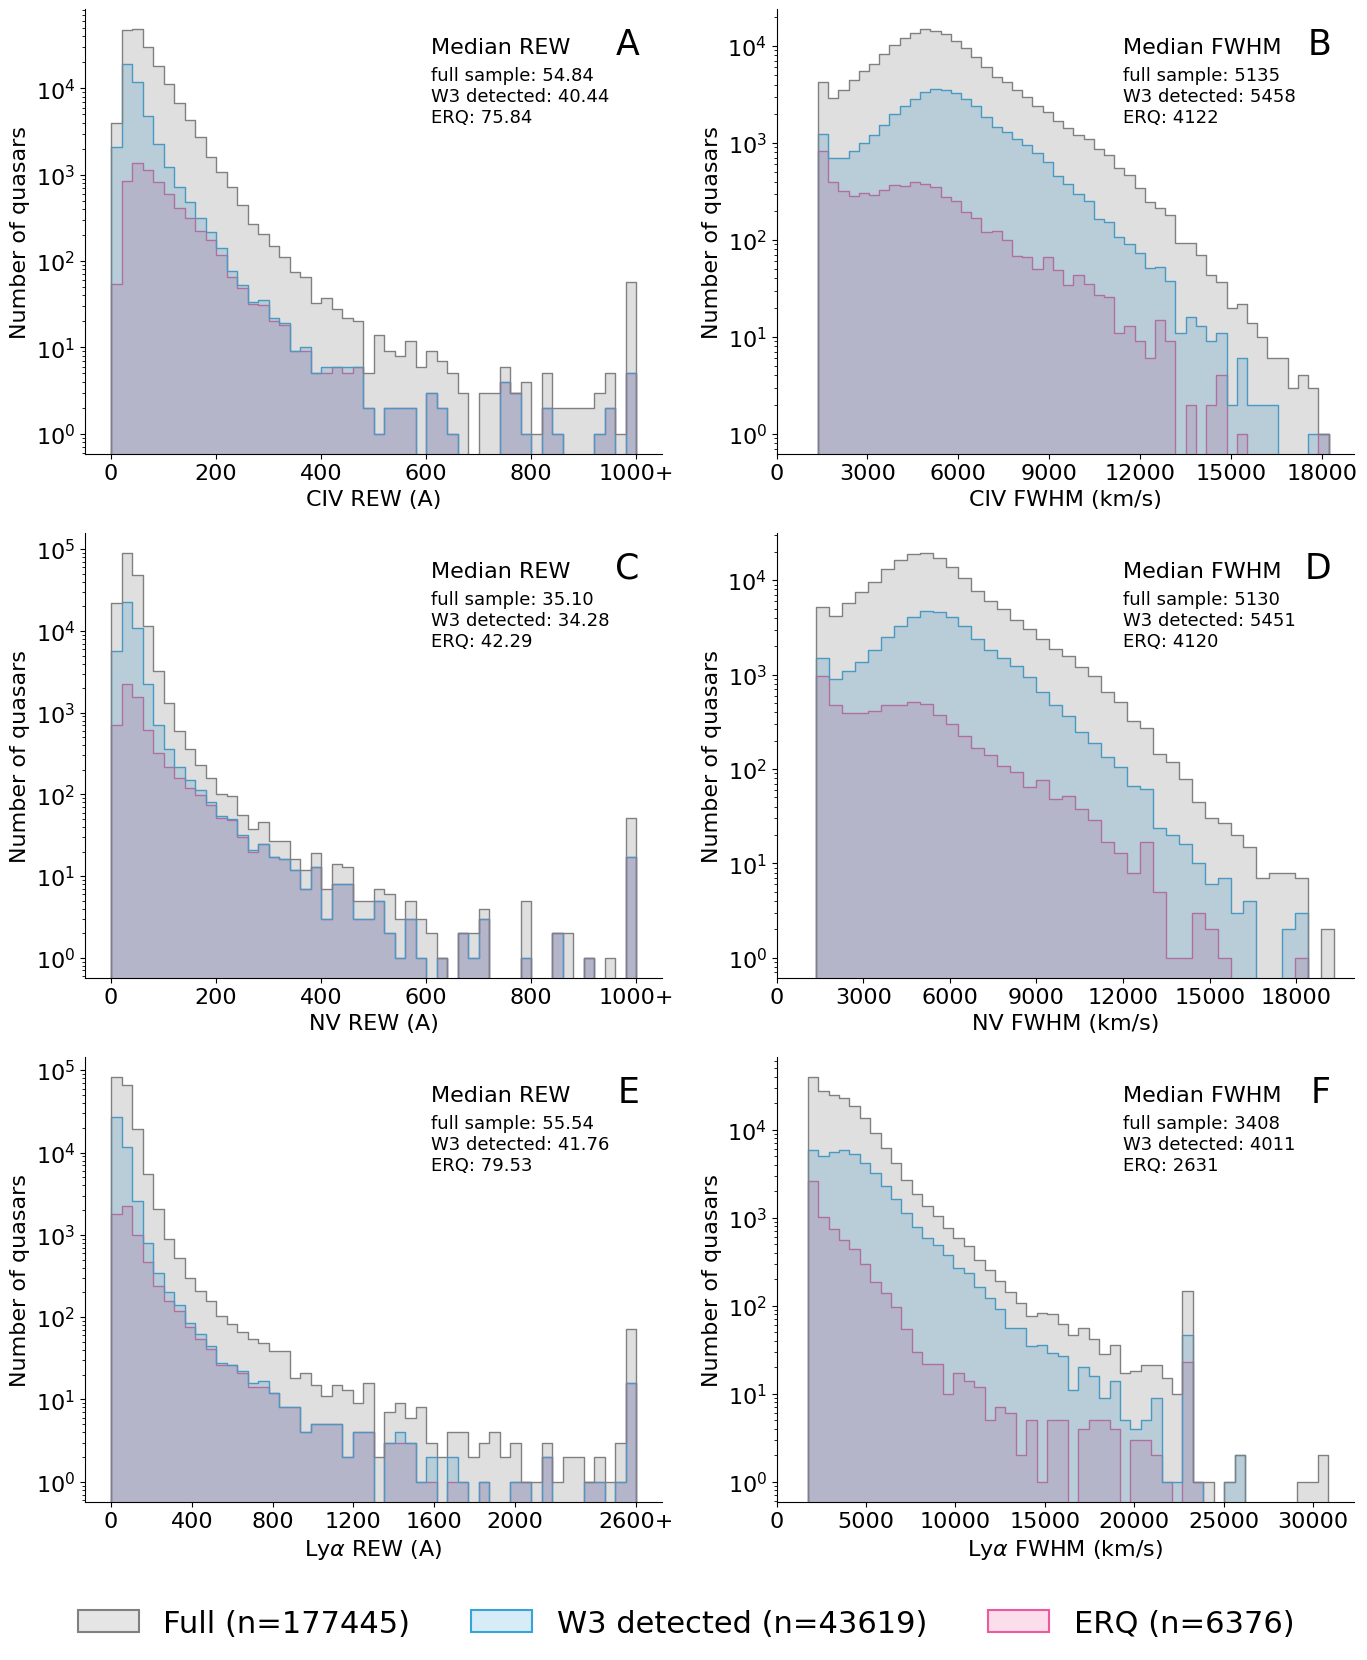

In [ ]:
fig, ax = plt.subplots(3,2,figsize=(14,16))


## CIV REW [0,0]

sns.histplot(data=civ_histplot, x="rew_civ", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[0,0],legend=False)

ax[0,0].set_yscale("log")

xticks_00 = list(range(0,1001,200))
ax[0,0].set_xticks(xticks_00)
xticklabels_00 = [str(int(t)) for t in xticks_00]
xticklabels_00[-1] = "1000+"
ax[0,0].set_xticklabels(xticklabels_00)

ax[0,0].set_xlabel("CIV REW (A)")
ax[0,0].set_ylabel("Number of quasars")
ax[0,0].spines[['right', 'top']].set_visible(False)

ax[0,0].text(0.6,0.9,f"Median REW",transform=ax[0,0].transAxes,fontsize=16)
ax[0,0].text(0.6,0.7,f"full sample: {full['rew_civ'].median():.2f}\nW3 detected: {w3_detected['rew_civ'].median():.2f}\nERQ: {erq['rew_civ'].median():.2f}\n",transform=ax[0,0].transAxes,fontsize=13)

## CIV FWHM [0,1]

sns.histplot(data=civ_histplot, x="fwhm_civ", hue="Sample", bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[0,1],legend=False)

ax[0,1].set_yscale("log")

xticks_01 = list(range(0,18001,3000))
ax[0,1].set_xticks(xticks_01)

ax[0,1].set_xlabel("CIV FWHM (km/s)")
ax[0,1].set_ylabel("Number of quasars")
ax[0,1].spines[['right', 'top']].set_visible(False)

ax[0,1].text(0.6,0.9,f"Median FWHM",transform=ax[0,1].transAxes,fontsize=16)
ax[0,1].text(0.6,0.7,f"full sample: {full['fwhm_civ'].median():.0f}\nW3 detected: {w3_detected['fwhm_civ'].median():.0f}\nERQ: {erq['fwhm_civ'].median():.0f}\n",transform=ax[0,1].transAxes,fontsize=13)

## NV REW [1,0]

sns.histplot(data=nv_histplot, x="rew_nv", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[1,0],legend=False)

ax[1,0].set_yscale("log")

xticks_10 = list(range(0,1001,200))
ax[1,0].set_xticks(xticks_10)
xticklabels_10 = [str(int(t)) for t in xticks_10]
xticklabels_10[-1] = "1000+"
ax[1,0].set_xticklabels(xticklabels_10)

ax[1,0].set_xlabel("NV REW (A)")
ax[1,0].set_ylabel("Number of quasars")
ax[1,0].spines[['right', 'top']].set_visible(False)

ax[1,0].text(0.6,0.9,f"Median REW",transform=ax[1,0].transAxes,fontsize=16)
ax[1,0].text(0.6,0.7,f"full sample: {full['rew_nv'].median():.2f}\nW3 detected: {w3_detected['rew_nv'].median():.2f}\nERQ: {erq['rew_nv'].median():.2f}\n",transform=ax[1,0].transAxes,fontsize=13)

## NV FWHM [1,1]

sns.histplot(data=nv_histplot, x="fwhm_nv", hue="Sample", bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[1,1],legend=False)

ax[1,1].set_yscale("log")

xticks_11 = list(range(0,18001,3000))
ax[1,1].set_xticks(xticks_11)

lower_x_11, _ = ax[1,1].get_xlim()
ax[1,1].set_xlim(lower_x_11, 20000)

ax[1,1].set_xlabel("NV FWHM (km/s)")
ax[1,1].set_ylabel("Number of quasars")
ax[1,1].spines[['right', 'top']].set_visible(False)

ax[1,1].text(0.6,0.9,f"Median FWHM",transform=ax[1,1].transAxes,fontsize=16)
ax[1,1].text(0.6,0.7,f"full sample: {full['fwhm_nv'].median():.0f}\nW3 detected: {w3_detected['fwhm_nv'].median():.0f}\nERQ: {erq['fwhm_nv'].median():.0f}\n",transform=ax[1,1].transAxes,fontsize=13)

## LYA REW [2,0]

sns.histplot(data=lya_histplot, x="rew_lya", hue="Sample",bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[2,0],legend=False)

ax[2,0].set_yscale("log")

xticks_20 = list(range(0,2001,400))+[2600]
ax[2,0].set_xticks(xticks_20)
xticklabels_20 = [str(int(t)) for t in xticks_20]
xticklabels_20[-1] = "2600+"
ax[2,0].set_xticklabels(xticklabels_20)

ax[2,0].set_xlabel(r"Ly$\alpha$ REW (A)")
ax[2,0].set_ylabel("Number of quasars")
ax[2,0].spines[['right', 'top']].set_visible(False)

ax[2,0].text(0.6,0.9,f"Median REW",transform=ax[2,0].transAxes,fontsize=16)
ax[2,0].text(0.6,0.7,f"full sample: {full['rew_lya'].median():.2f}\nW3 detected: {w3_detected['rew_lya'].median():.2f}\nERQ: {erq['rew_lya'].median():.2f}\n",transform=ax[2,0].transAxes,fontsize=13)

## LYA FWHM [2,1]

sns.histplot(data=lya_histplot, x="fwhm_lya", hue="Sample", bins=50,element="step",hue_order=hue_order,palette=hist_palette,ax=ax[2,1],legend=False)

ax[2,1].set_yscale("log")

ax[2,1].set_xlabel(r"Ly$\alpha$ FWHM (km/s)")
ax[2,1].set_ylabel("Number of quasars")
ax[2,1].spines[['right', 'top']].set_visible(False)

xticks_21 = ax[2,1].get_xticks()
ax[2,1].set_xticks([0]+xticks_21[:-1])

ax[2,1].text(0.6,0.9,f"Median FWHM",transform=ax[2,1].transAxes,fontsize=16)
ax[2,1].text(0.6,0.7,f"full sample: {full['fwhm_lya'].median():.0f}\nW3 detected: {w3_detected['fwhm_lya'].median():.0f}\nERQ: {erq['fwhm_lya'].median():.0f}\n",transform=ax[2,1].transAxes,fontsize=13)

## GLOBAL STYLE THINGS

# letters in upper right corner
labels = ['A', 'B', 'C', 'D', 'E', 'F']

for a, letter in zip(ax.flat, labels):
    a.text(
        0.96, 0.96, f"{letter}",
        transform=a.transAxes,
        ha='right', va='top',
        fontsize=25,
    )



# ax[0,0].text(
#         0.96, 0.96, f"Full sample median REW = {full['rew_civ'].median()}",
#         transform=a.transAxes,
#         ha='right', va='top',
#         fontsize=10,
#     )

# legend
handles = [
    Patch(
        facecolor=mcolors.to_rgba(c, alpha=0.2),  # transparent fill
        edgecolor=c,
        linewidth=1.5,
    )
    for c in hist_palette
]



leg = fig.legend(
    handles, labels_legend,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(handles),
    frameon=False,
    fontsize=22,
    markerscale=4
)


plt.tight_layout()

# plt.savefig("images/histograms_v1.svg")

plt.show()

In [34]:
full

,rew_civ,rew_nv,rew_lya,snr_1700A,snr_civ,snr_nv,snr_lya,pixel_used_civ,pixel_used_blue_end_lya,continuum_redchi,...,fit_rew_nv,fit_rew_lya,flux_civ,flux_nv,flux_lya,fwhm_civ,fwhm_nv,fwhm_lya,kt80_civ,Sample
targetid,,,,,,,,,,,,,,,,,,,,,
39628261600268308,39.031205,31.724235,78.680152,0.667813,17.919601,11.823770,28.986812,1.000000,0.819444,0.051630,...,30.873547,79.327994,1578.572653,1755.868659,4467.502691,3253.396449,3251.881116,2260.575301,0.249399,Full
39628513032014681,99.921235,35.019969,80.101368,0.744331,10.196423,3.833103,9.706395,0.963415,0.858696,0.035859,...,39.221570,80.179306,702.093410,373.690555,886.189289,5004.121189,4996.055063,2496.704981,0.238525,Full
39627901502489216,61.661126,50.066402,56.991357,0.736838,6.510926,4.934822,8.353253,0.962441,0.832898,0.150371,...,51.046492,63.236045,238.614723,241.211185,280.171174,5395.436113,5387.128039,4360.419360,0.234584,Full
39628528513191306,36.619786,62.312266,22.472902,0.732648,8.464268,8.983848,11.937892,0.894349,0.683060,1.702749,...,67.106677,30.577277,908.245722,1909.709200,696.782583,7004.388592,6992.688130,3046.948259,0.324565,Full
39627866769461108,69.769428,49.154418,41.867135,0.560333,10.323005,10.383644,16.522289,0.997835,0.773494,1.284817,...,52.529956,42.194407,881.968932,850.503658,742.675782,7365.153111,7353.267331,4962.357216,0.226158,Full
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39628053415987103,118.962903,49.831986,92.167040,0.680706,2.613462,0.727741,1.646045,0.920596,0.889807,0.038240,...,45.596857,100.022424,84.395460,41.496963,78.308778,4527.744460,4535.865791,4139.097371,0.231864,Full
39627983115257786,52.601683,27.833232,38.173872,0.953028,8.233751,6.199389,12.435801,0.997835,0.828916,0.280892,...,33.765478,41.641763,641.849498,428.851538,603.353178,6748.325156,6737.115628,5221.039957,0.242868,Full
39627926517322439,88.433732,33.716419,139.284764,0.519953,12.028317,5.543115,18.376339,0.950108,0.840580,0.050119,...,32.918452,138.756640,197.663768,105.628622,450.723156,2341.986219,2341.278198,2033.014791,0.270749,Full


In [22]:
len(civ_histplot[civ_histplot["Sample"]=="Full"])

177445

In [37]:
hue_order
labels_legend = [f"Full (n={len(full)})",f"W3 detected (n={len(w3_detected)})", f"ERQ (n={len(erq)})"]

In [20]:
full[["fwhm_civ","fwhm_nv","fwhm_lya"]].describe()

,fwhm_civ,fwhm_nv,fwhm_lya
count,177400.000000,177346.000000,177358.000000
mean,5345.673061,5341.747184,3847.425869
std,2069.283645,2070.355572,2025.266506
min,1367.210673,1365.329927,1742.625254
25%,4021.318813,4018.672102,2415.315973
50%,5135.252247,5129.526504,3407.591604
75%,6380.020705,6372.251249,4628.304305
max,18229.332175,23788.928605,30844.539955


In [21]:
(full["fwhm_civ"] > 2000).mean()

0.9613852179548592

#### i-W3 histogram

In [12]:
color_hist_df = w3_detected[w3_detected["rew_civ"]>100].copy()
color_hist_df["Sample"] = "REW(CIV) > 100"
color_hist_df = pd.concat([color_hist_df,w3_detected])[["z-w3","Sample"]]

# color_hist_df

[]

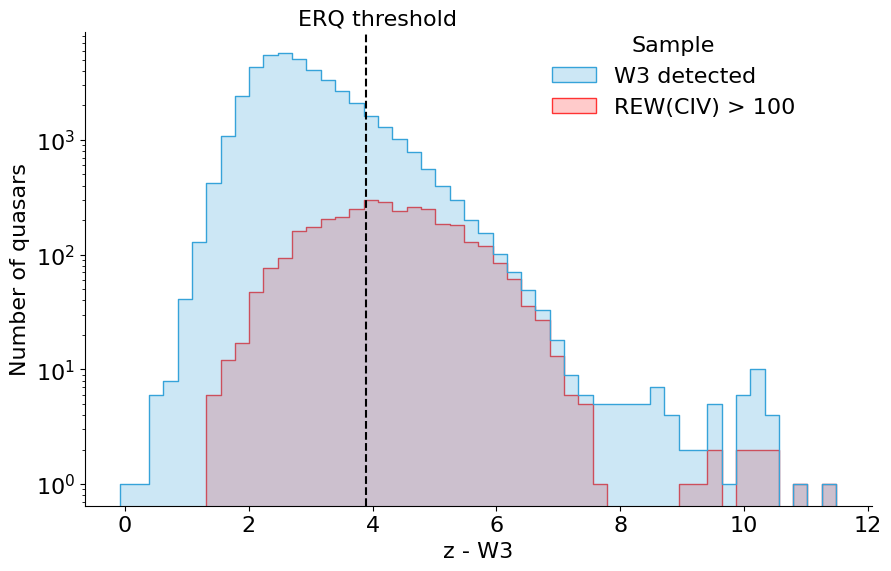

In [ ]:
g = sns.displot(data=color_hist_df, x="z-w3", hue="Sample",bins=50,element="step",hue_order=["W3 detected","REW(CIV) > 100"],palette=[palette_dark[2],palette_dark[5]],height=6,aspect=1.1)

plt.yscale("log")

plt.xlabel("z - W3")
plt.ylabel("Number of quasars")

plt.axvline(3.9,color="black",label="ERQ threshold",linestyle="--")
plt.text(2.8,10000,"ERQ threshold")

sns.move_legend(g,"upper right",bbox_to_anchor=(0.9,0.95))

plt.tight_layout()

# plt.savefig("images/color_hist.svg")

plt.plot()

#### NV/CIV vs color

In [13]:
# dataframe where the subsets are not duplicate like for the histograms
w3_copy_df = w3_detected[["z-w3","flux_civ","flux_nv","flux_lya","rew_civ","kt80_civ","Sample","z"]].copy()
w3_copy_df["nv/civ"] = w3_copy_df["flux_nv"] / w3_copy_df["flux_civ"]
w3_copy_df["nv/lya"] = w3_copy_df["flux_nv"] / w3_copy_df["flux_lya"]

for elem in w3_copy_df.index:
    if w3_copy_df.loc[elem,"rew_civ"] > 100:
        w3_copy_df.loc[elem,"Sample"] = "REW(CIV) > 100"

w3_copy_df = w3_copy_df.reset_index()

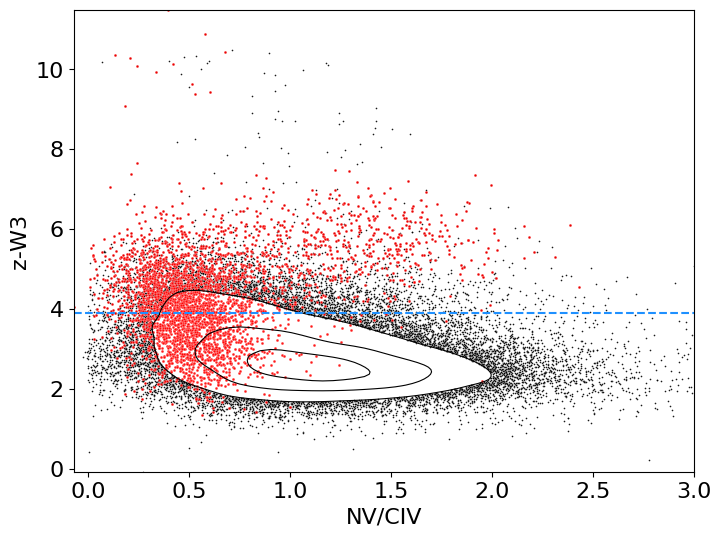

In [59]:
contour_scatter_plot(w3_copy_df,x="nv/civ",y="z-w3",upper_x_lim=3,x_label="NV/CIV",y_label="z-W3")

In [14]:
w3_copy_df["rew_civ_log"] = np.log10(w3_copy_df["rew_civ"].values)

/tmp/ipykernel_69141/3947095523.py:1: RuntimeWarning: divide by zero encountered in log10
  w3_copy_df["rew_civ_log"] = np.log10(w3_copy_df["rew_civ"].values)


In [25]:
details = pd.read_csv(DETAILS_PATH,index_col=0,dtype={"targetid":"str"})
kt80_df = w3_copy_df[w3_copy_df["kt80_civ"].notna()].merge(details,left_index=True,right_index=True,how="left").drop(columns=["targetid_y"]).rename(columns={"targetid_x":"targetid"}).set_index("targetid")

for idx in kt80_df.index:
    kt80_df.loc[idx,"accept_two_civ"] = ast.literal_eval(kt80_df.loc[idx,"line_fit_civ"])["accept_two"]

/tmp/ipykernel_69141/3651255298.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  kt80_df.loc[idx,"accept_two_civ"] = ast.literal_eval(kt80_df.loc[idx,"line_fit_civ"])["accept_two"]


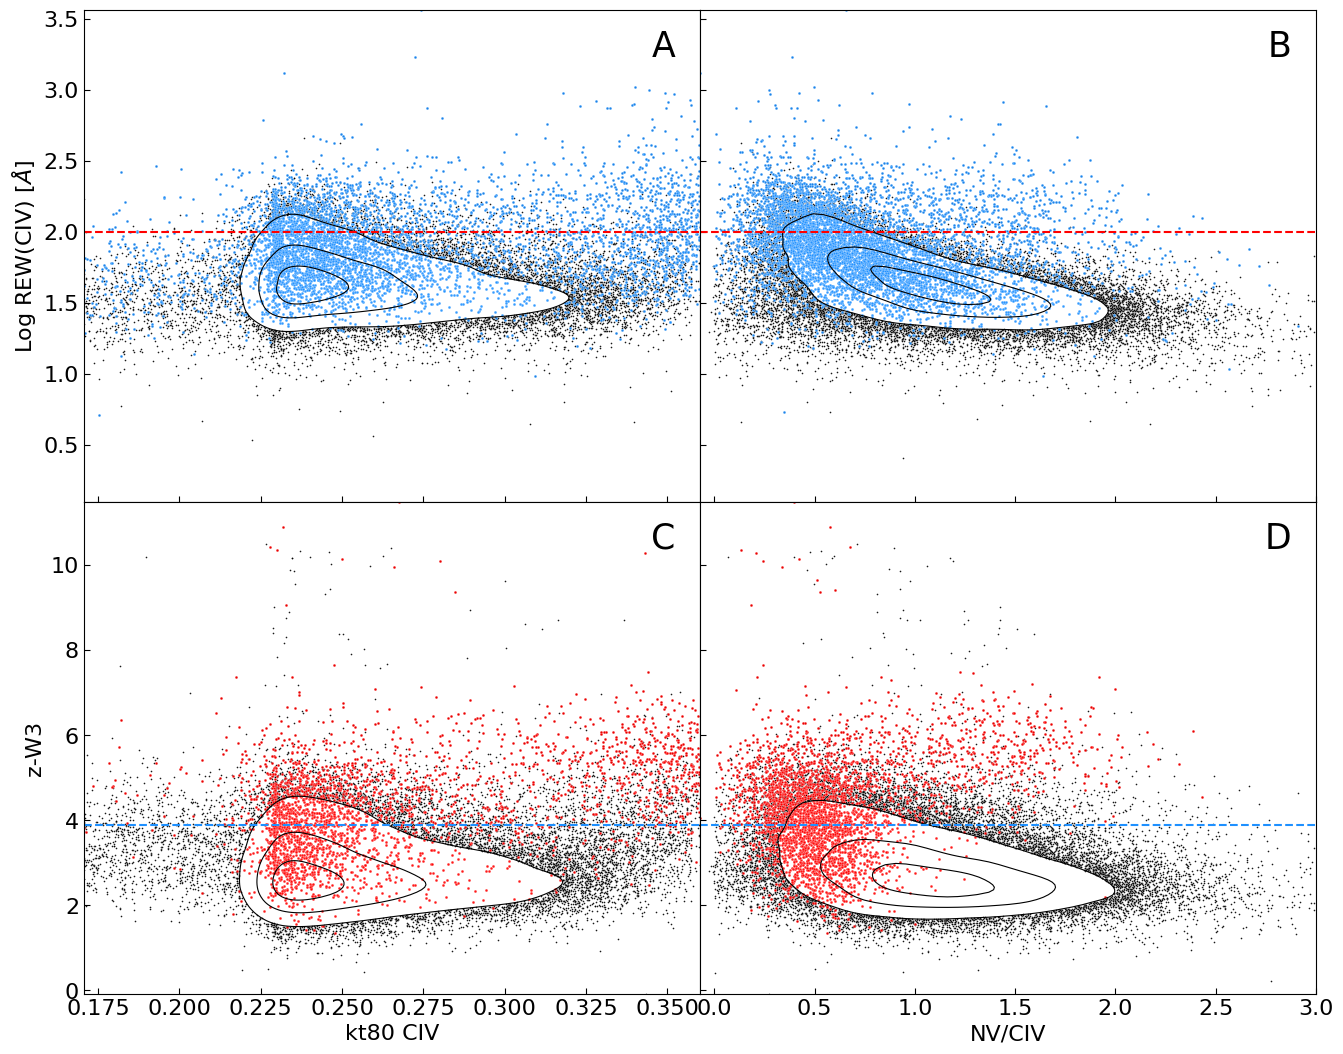

In [38]:
fig, axes = plt.subplots(2,2,figsize=(14,12),sharex="col",sharey="row")

contour_scatter_plot(kt80_df[(kt80_df["kt80_civ"]<0.36)&(np.isfinite(kt80_df["rew_civ_log"]))],x="kt80_civ",y="rew_civ_log",x_label="kt80 CIV",y_label=r"Log REW(CIV) [$\AA$]",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=2,y_threshold_label="Core ERQ threshold",ax=axes[0,0],threshold_color="red",subsample_color="DodgerBlue")

contour_scatter_plot(w3_copy_df[(np.isfinite(w3_copy_df["rew_civ_log"]))],x="nv/civ",y="rew_civ_log",upper_x_lim=3,x_label="NV/CIV",y_label=r"Log REW(CIV) [$\AA$]",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=2,y_threshold_label="Core ERQ threshold",ax=axes[0,1],threshold_color="red",subsample_color="DodgerBlue")

contour_scatter_plot(kt80_df[kt80_df["kt80_civ"]<0.36],x="kt80_civ",y="z-w3",x_label="kt80 CIV",y_label="z-W3",subsample_col="rew_civ",subsample_cutoff=100,ax=axes[1,0])

contour_scatter_plot(w3_copy_df,x="nv/civ",y="z-w3",upper_x_lim=3,x_label="NV/CIV",y_label="z-W3",ax=axes[1,1])

fig.subplots_adjust(
    left=0.1, right=0.98, bottom=0.1, top=0.92,
    wspace=0, hspace=0                             
)

labels = ['A', 'B', 'C', 'D', 'E', 'F']

for a, letter in zip(axes.flat, labels):
    a.text(
        0.96, 0.96, f"{letter}",
        transform=a.transAxes,
        ha='right', va='top',
        fontsize=25,
    )

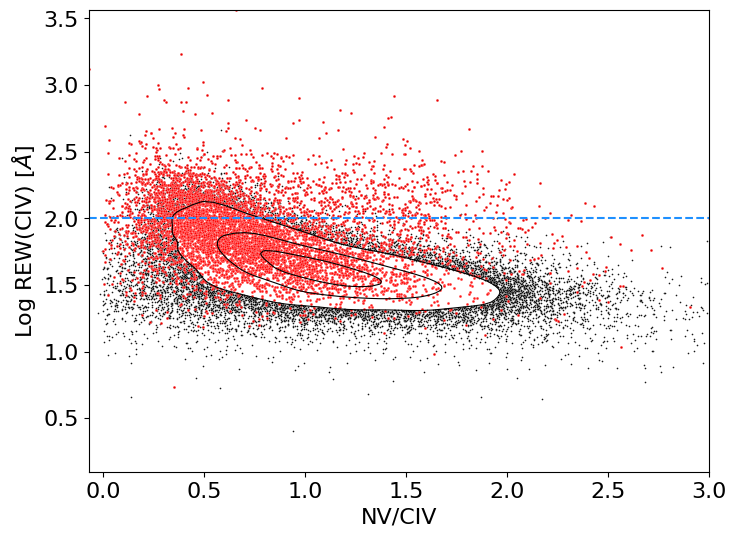

In [17]:
contour_scatter_plot(w3_copy_df[(np.isfinite(w3_copy_df["rew_civ_log"]))],x="nv/civ",y="rew_civ_log",upper_x_lim=3,x_label="NV/CIV",y_label=r"Log REW(CIV) [$\AA$]",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=2,y_threshold_label="Core ERQ threshold")

#### NV/Lya vs color

In [52]:
w3_copy_df.query("flux_lya>0 & flux_nv>0").groupby("Sample")["nv/lya"].describe().T

Sample,REW(CIV) > 100,W3 detected
count,3444.000000,40162.000000
mean,0.636569,1.371733
std,1.091057,11.961557
min,0.004542,0.000929
25%,0.314275,0.541362
50%,0.487100,0.836956
75%,0.741465,1.269607
max,53.837090,1876.691339


In [59]:
w3_copy_df[(w3_copy_df["flux_lya"]>0) & (w3_copy_df["flux_nv"]>0) & (w3_copy_df["z-w3"]>3.9)]["nv/lya"].describe().T

count    6375.000000
mean        0.892774
std         6.519884
min         0.001274
25%         0.335118
50%         0.557107
75%         0.886486
max       495.254820
Name: nv/lya, dtype: float64

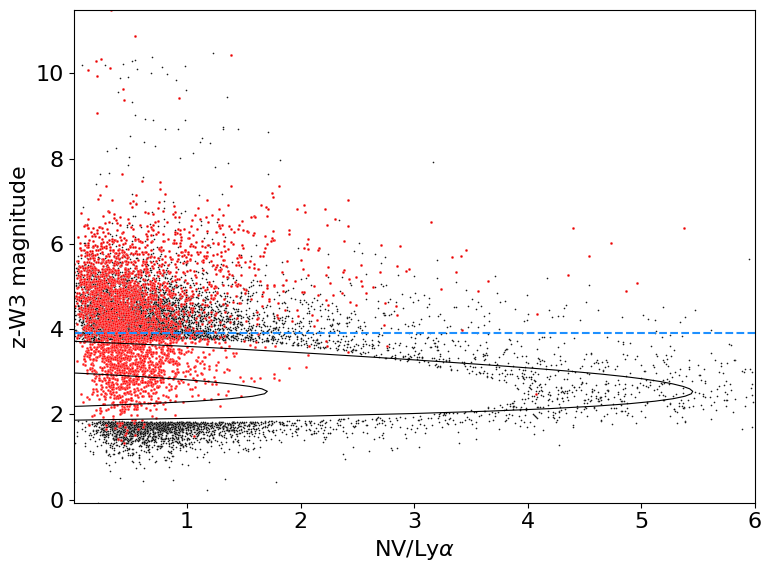

In [ ]:
contour_scatter_plot(w3_copy_df.query("flux_lya>0 & flux_nv>0"),x="nv/lya",y="z-w3",x_label=r"NV/Ly$\alpha$",y_label="z-W3",upper_x_lim=6)

#### kt80 vs color

In [ ]:
# kt80_vs_color_df = w3_copy_df[w3_copy_df["kt80_civ"].notna()][["kt80_civ","z-w3"]].copy()

# k = kt80_vs_color_df[["kt80_civ","z-w3"]].values.T
# kde_kt80_vs_color = gaussian_kde(k)
# kt80_vs_color_df["density"] = kde_kt80_vs_color(k)

In [16]:
kt80_df.accept_two_civ.value_counts()

accept_two_civ
True     27580
False    14502
Name: count, dtype: int64

In [55]:
print(f"Fraction of quasars with 'wingless' (kt80 > 0.33) CIV profiles\nFull sample:\t{(full['kt80_civ']>0.33).mean():.3f}\nW3 detected:\t{(full[full['snr_w3']>3]['kt80_civ']>0.33).mean():.3f}\nERQs:\t\t{(kt80_df[kt80_df['z-w3']>3.9]['kt80_civ']>0.33).mean():.3f}\nCore ERQ:\t{(kt80_df[(kt80_df['z-w3']>3.9)&(kt80_df['rew_civ']>100)]['kt80_civ']>0.33).mean():.3f}")

Fraction of quasars with 'wingless' (kt80 > 0.33) CIV profiles
Full sample:	0.155
W3 detected:	0.194
ERQs:		0.283
Core ERQ:	0.342


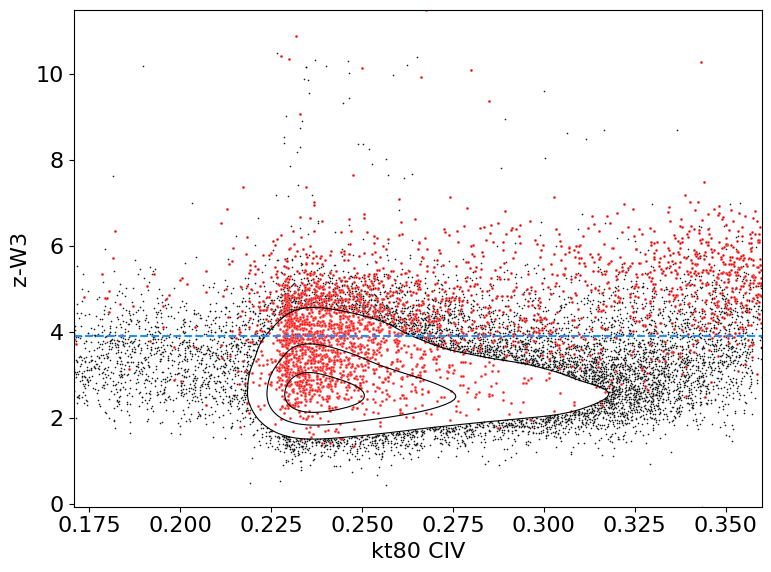

In [21]:
contour_scatter_plot(kt80_df[kt80_df["kt80_civ"]<0.36],x="kt80_civ",y="z-w3",x_label="kt80 CIV",y_label="z-W3",subsample_col="rew_civ",subsample_cutoff=100)

In [25]:
kt80_df["rew_civ_log"] = np.log10(kt80_df["rew_civ"].values)

/tmp/ipykernel_14362/3765453264.py:1: RuntimeWarning: divide by zero encountered in log10
  kt80_df["rew_civ_log"] = np.log10(kt80_df["rew_civ"].values)


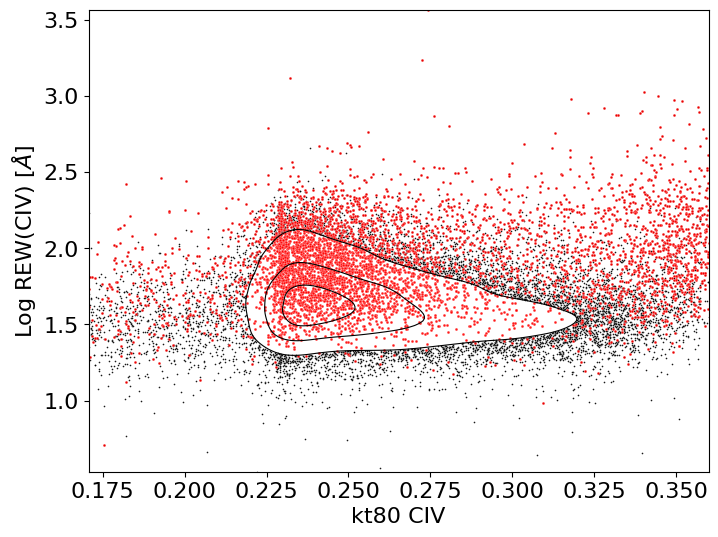

In [ ]:
# with pd.option_context('mode.use_inf_as_null', True):
contour_scatter_plot(kt80_df[(kt80_df["kt80_civ"]<0.36)&(np.isfinite(kt80_df["rew_civ_log"]))],x="kt80_civ",y="rew_civ_log",x_label="kt80 CIV",y_label=r"Log REW(CIV) [$\AA$]",subsample_col="z-w3",subsample_cutoff=3.9,y_threshold=100,y_threshold_label="Core ERQ threshold")

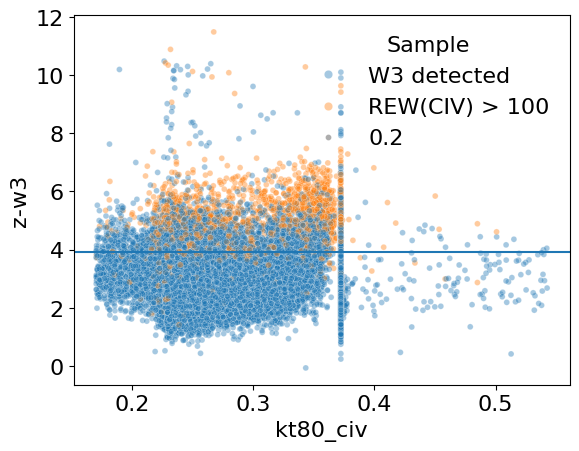

In [62]:
sns.scatterplot(data=w3_copy_df,x="kt80_civ",y="z-w3",hue="Sample",size=0.2,alpha=0.4)


plt.axhline(y=3.9)

# plt.xlim(-0.1,3.5)

#### Contour plot: z vs color

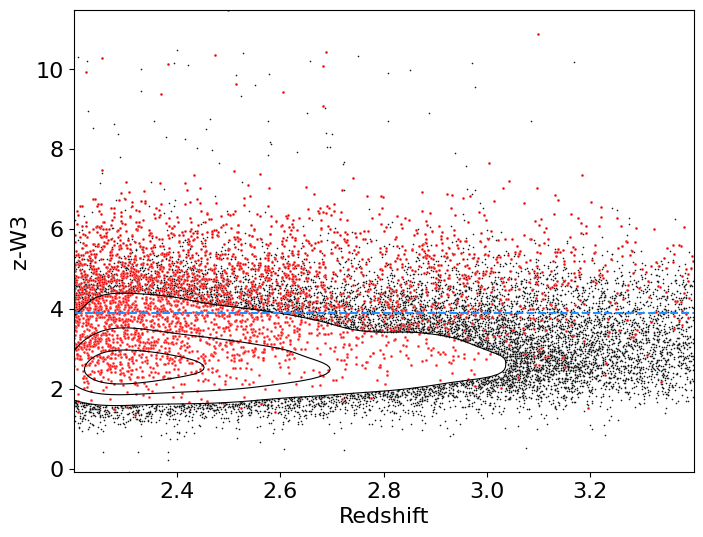

In [58]:
contour_scatter_plot(w3_copy_df,x="z",y="z-w3",x_label="Redshift",y_label="z-W3")